# FinSight: Exploratory Data Analysis

This notebook presents the Day 2 analysis of the validated UCI Statlog German Credit data. Reusable loading, validation, EDA, splitting, and preprocessing logic lives in `src/`; the notebook is intentionally a narrative layer. No model is trained or tuned here. Full-dataset EDA is descriptive; all fitted preprocessing uses training rows only.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src.data.eda import build_eda_summary, create_eda_figures
from src.data.load_data import load_data
from src.data.validate import validate_dataset
from src.data.preprocess import prepare_data, write_analytics_dataset

frame = load_data(PROJECT_ROOT / 'data/raw/german.data')
validation = validate_dataset(frame)
validation.raise_for_errors()
summary = build_eda_summary(frame)
plots = create_eda_figures(frame, PROJECT_ROOT / 'outputs/plots')
frame.shape, validation.is_valid

((1000, 21), True)

## Data quality and target

Completeness, duplicates, invalid values, and class balance are computed below. The source target remains `1 = good` and `2 = bad`; preprocessing later maps bad risk to binary class 1.

In [2]:
display(pd.DataFrame(summary['class_distribution']).T)
display(pd.Series(summary['data_quality'], name='data_quality'))

,code,count,percent
good,1.0,700.0,70.0
bad,2.0,300.0,30.0


rows                     1000
columns                    21
completeness_percent    100.0
missing_values              0
duplicate_rows              0
invalid_values              0
validation_errors          []
validation_warnings        []
Name: data_quality, dtype: object

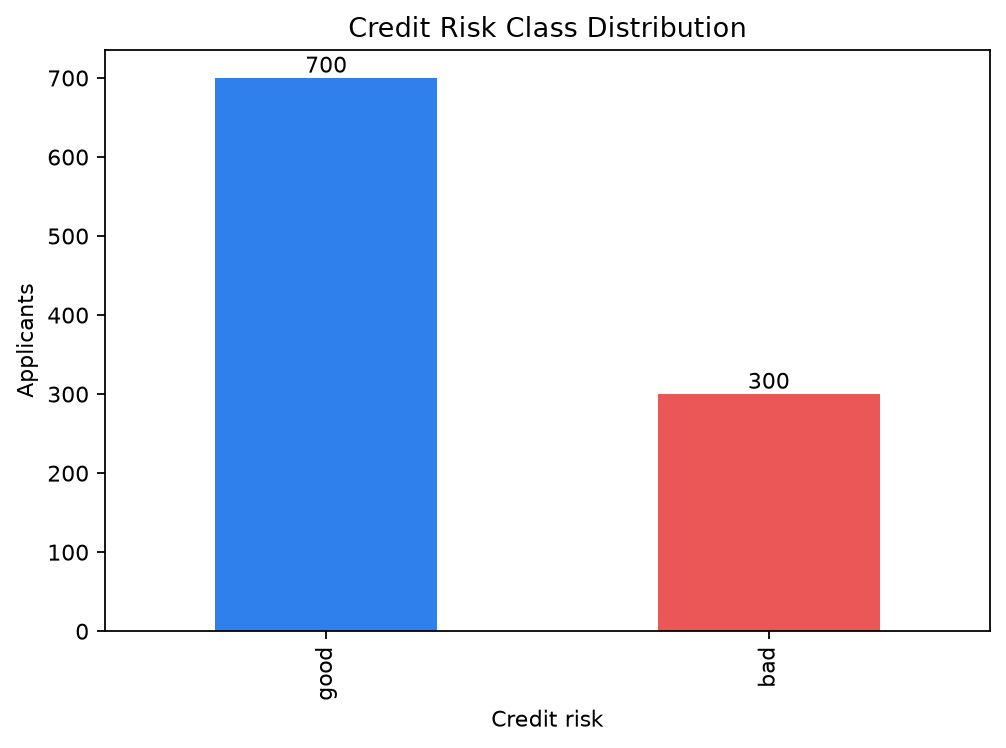

In [3]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/plots/target_distribution.png')))

## Numeric distributions and unusual values

The IQR rule identifies potential outliers for discussion only. Values are not removed or capped because large loans, long durations, and older applicants may be valid records.

In [4]:
pd.DataFrame(summary['potential_outliers_iqr']).T

,q1,q3,lower_fence,upper_fence,potential_outliers
duration_months,12.0,24.00,-6.00,42.00,70.0
credit_amount,1365.5,3972.25,-2544.62,7882.38,72.0
installment_rate,2.0,4.00,-1.00,7.00,0.0
residence_duration,2.0,4.00,-1.00,7.00,0.0
age_years,27.0,42.00,4.50,64.50,23.0
existing_credits,1.0,2.00,-0.50,3.50,6.0
dependents,1.0,1.00,1.00,1.00,155.0


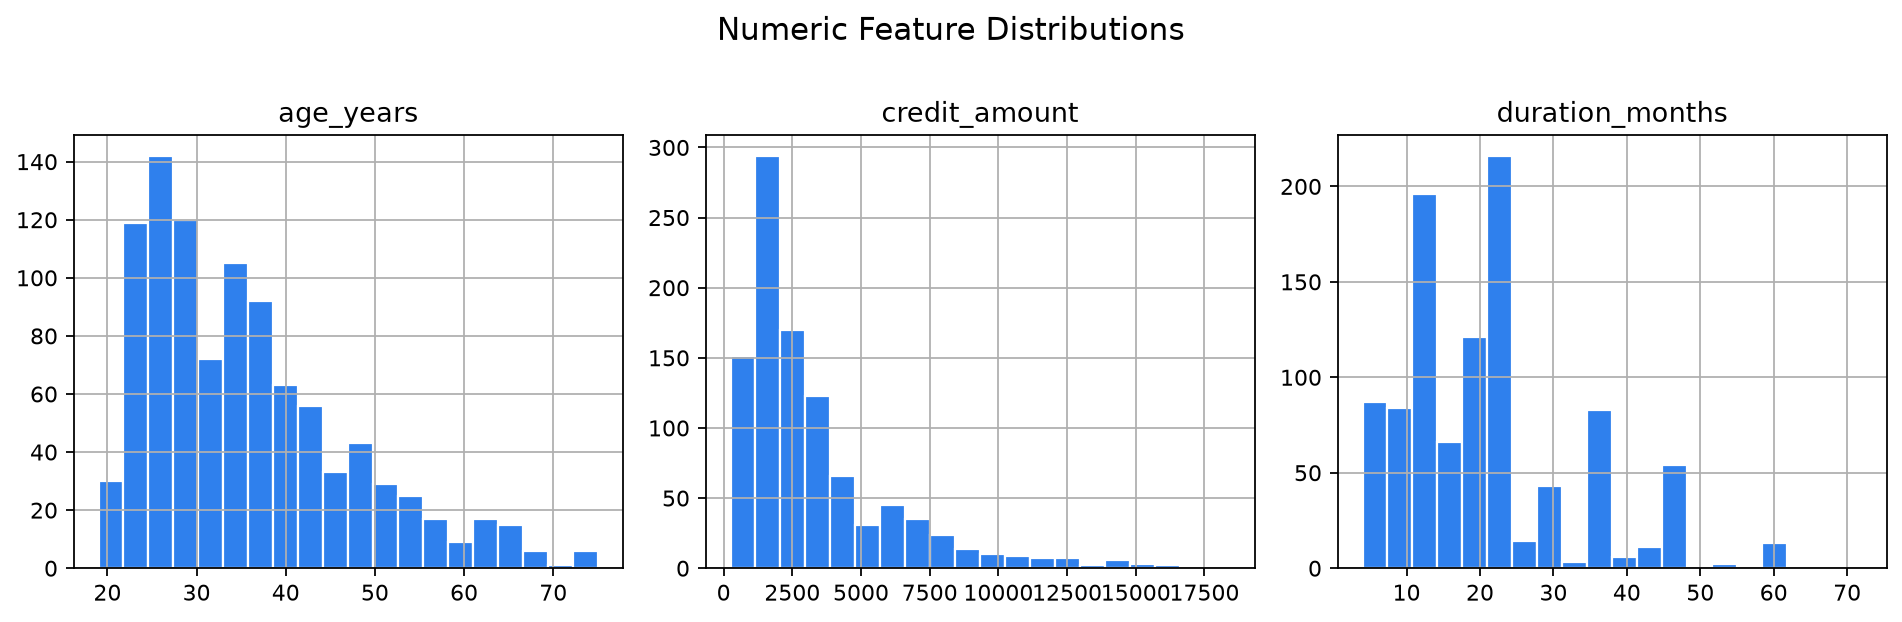

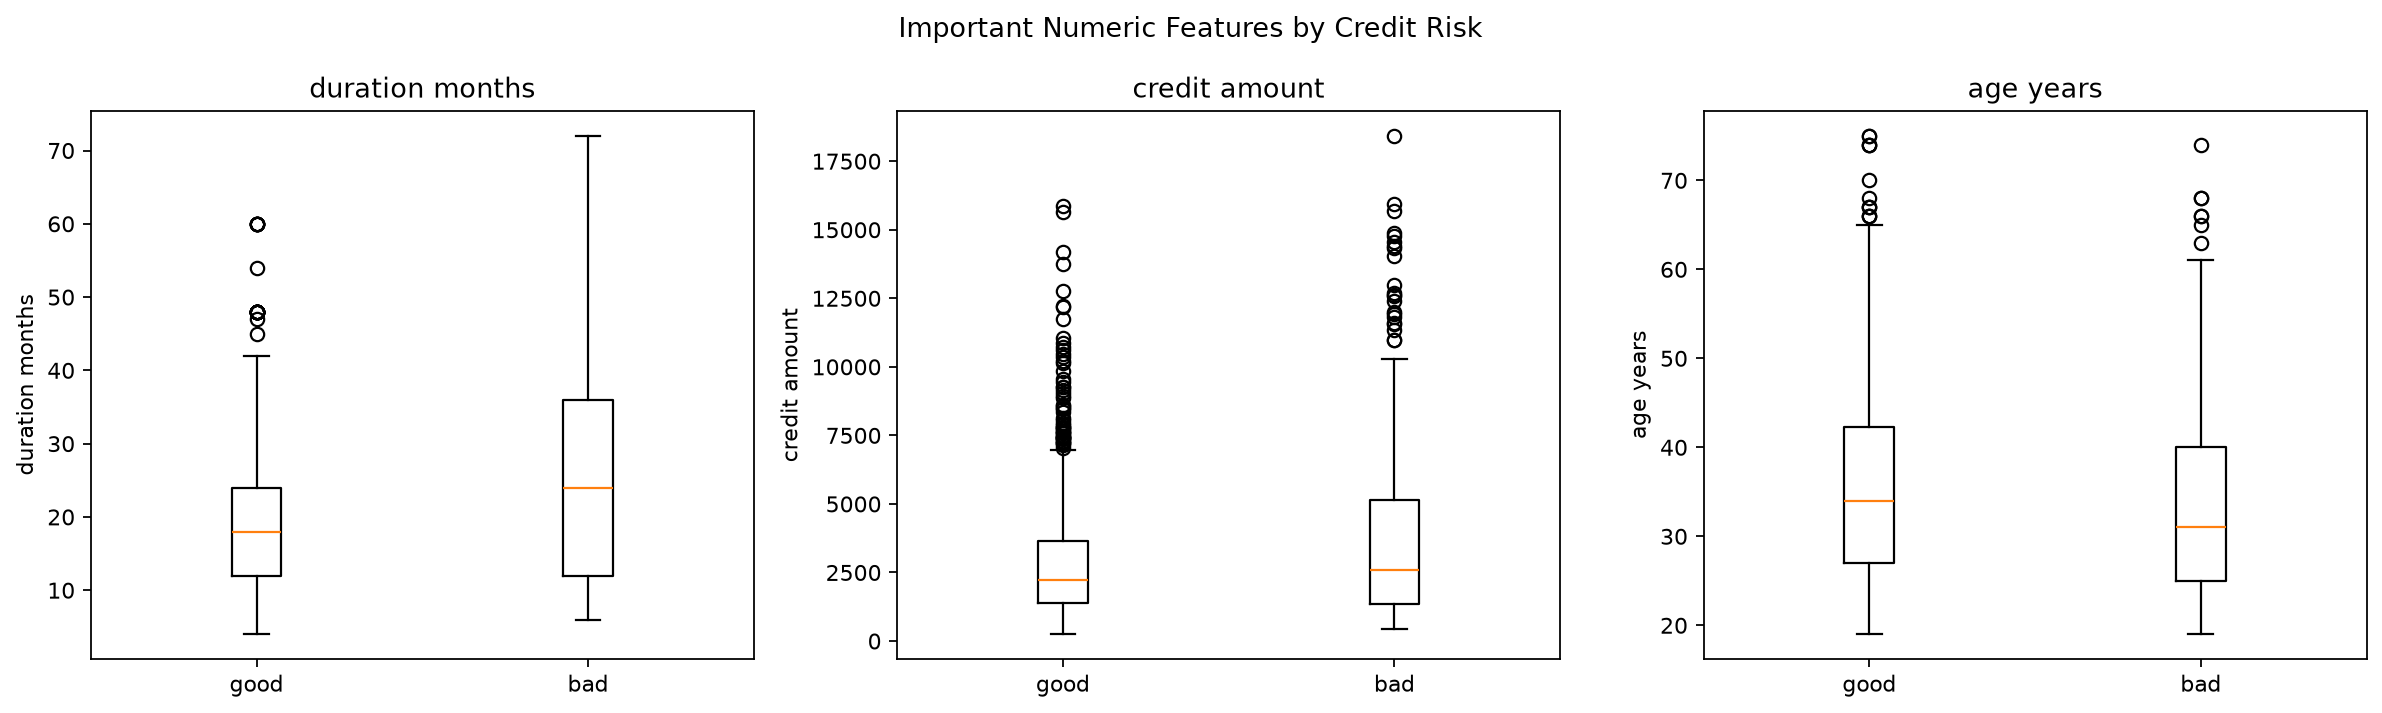

In [5]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/plots/numeric_distributions.png')))
display(Image(filename=str(PROJECT_ROOT / 'outputs/plots/numeric_risk_relationships.png')))

## Categorical distributions and credit-risk relationships

Category-level bad-risk rates are descriptive associations, not causal effects. Several fields are sensitive or potential proxies and require fairness review before any real decision use.

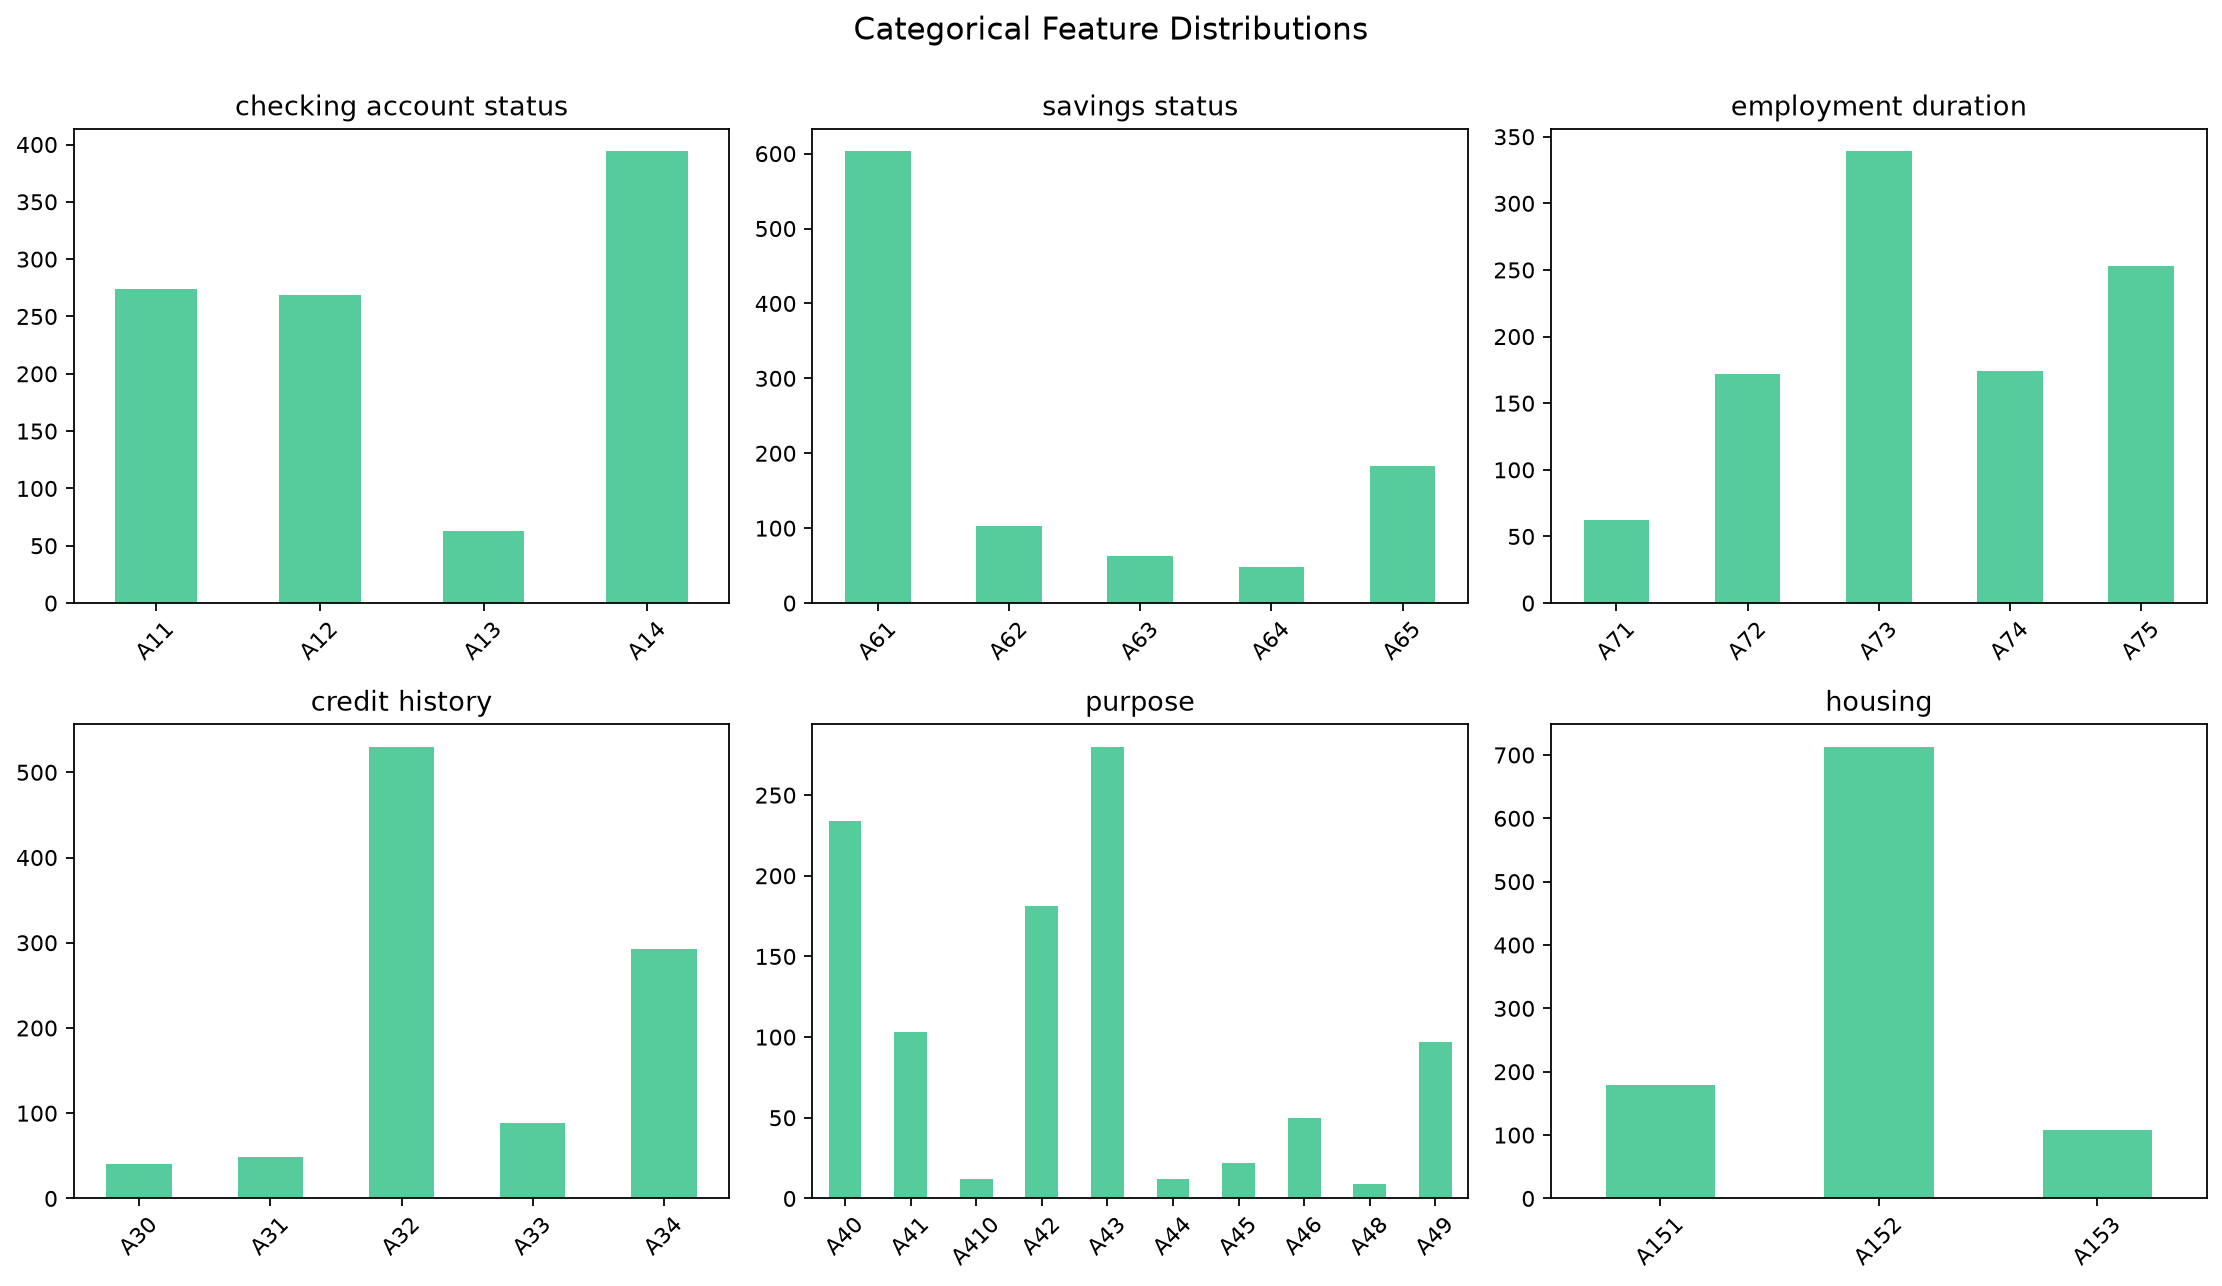

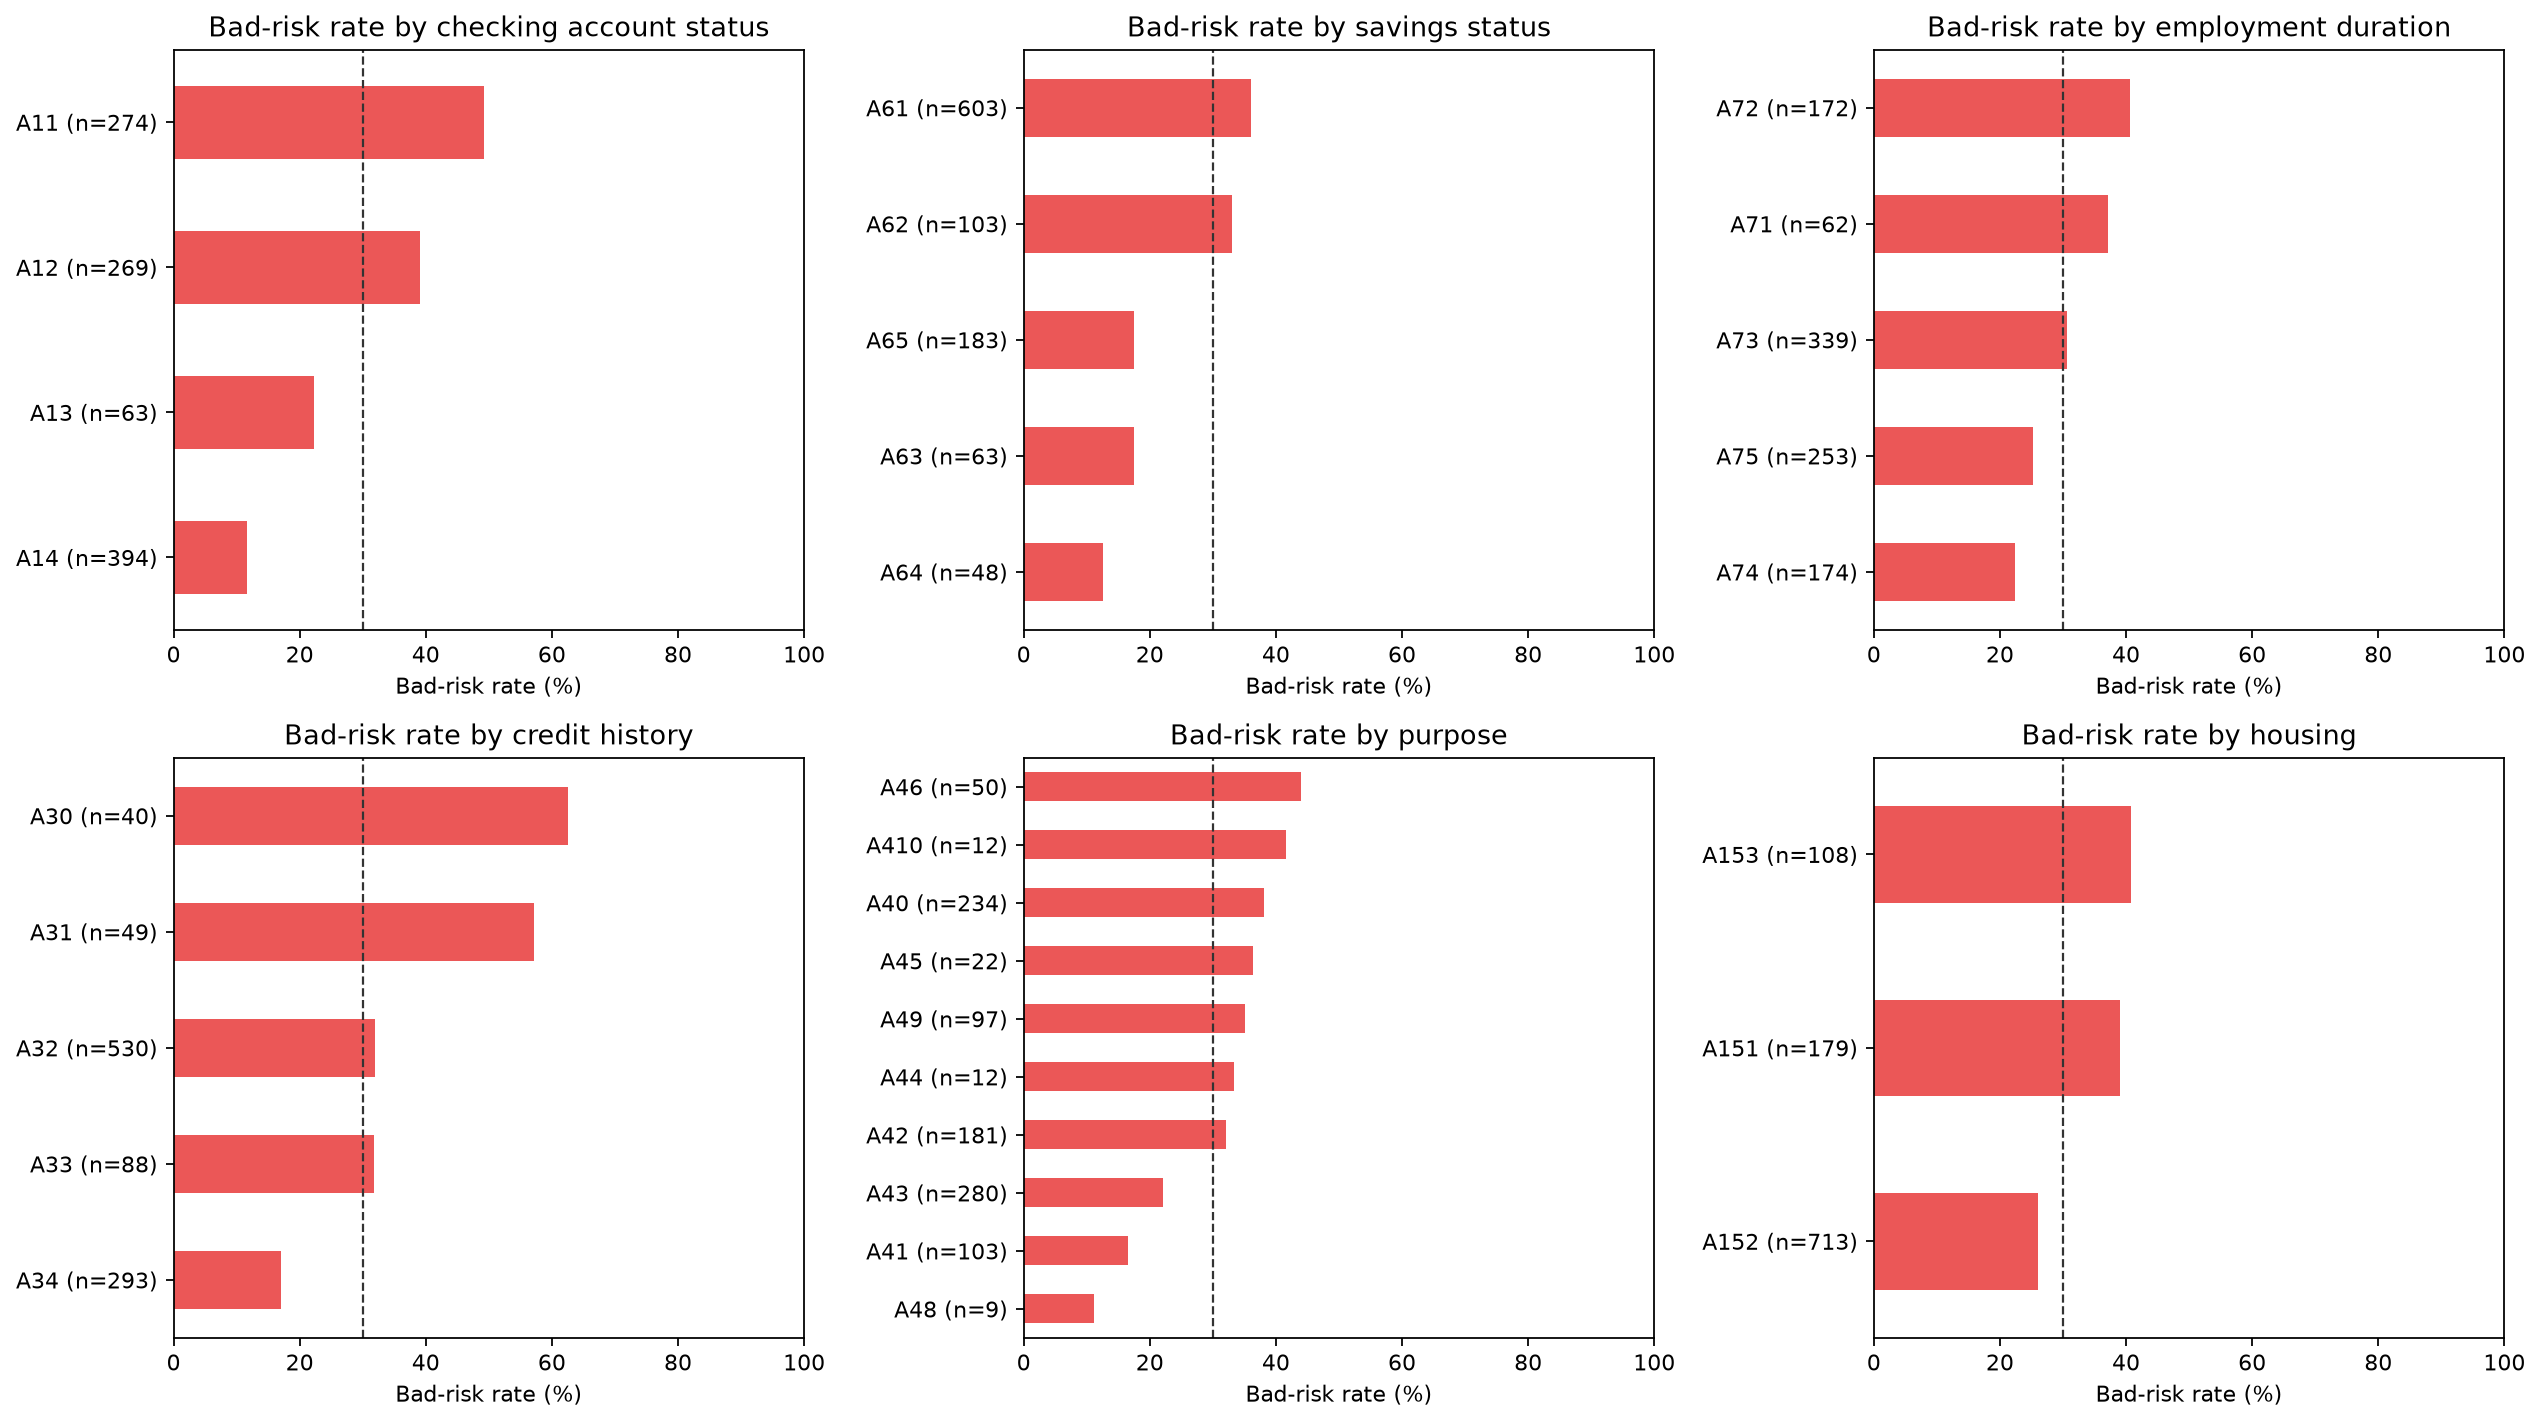

In [6]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/plots/categorical_distributions.png')))
display(Image(filename=str(PROJECT_ROOT / 'outputs/plots/categorical_risk_relationships.png')))

## Leakage-safe preprocessing demonstration

The split occurs on raw rows with stratification. Only the training partition is used to fit imputation, scaling, and one-hot categories. A complete estimator should be attached with `build_model_pipeline`, ensuring identical transformations at inference.

In [7]:
prepared = prepare_data(frame, scale_numeric=True, test_size=0.2, random_state=42)
split = prepared.split
X_train_transformed = prepared.X_train
X_test_transformed = prepared.X_test
{
    'raw_train_shape': split.X_train.shape,
    'raw_test_shape': split.X_test.shape,
    'transformed_train_shape': X_train_transformed.shape,
    'transformed_test_shape': X_test_transformed.shape,
    'train_bad_rate': split.y_train.mean(),
    'test_bad_rate': split.y_test.mean(),
}

{'raw_train_shape': (800, 20),
 'raw_test_shape': (200, 20),
 'transformed_train_shape': (800, 61),
 'transformed_test_shape': (200, 61),
 'train_bad_rate': np.float64(0.3),
 'test_bad_rate': np.float64(0.3)}

## Analytics export for S3 / Glue / Athena
The CSV retains all original features and codes, adds source-row `applicant_id`, readable `credit_risk_label`, and binary `is_bad_risk`. It is unscaled and unencoded for SQL analytics. Never feed the ID or target-derived columns into ML preprocessing. See `reports/day2_aws_setup.md`.

In [8]:
analytics_path = write_analytics_dataset(frame)
analytics = pd.read_csv(analytics_path)
display(analytics.head())
analytics_path, analytics.shape

,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_duration,installment_rate,personal_status_sex,...,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk,credit_risk_label,is_bad_risk
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


(WindowsPath('D:/Data Science/FinSight/data/processed/german_credit_analytics.csv'),
 (1000, 24))

## Conclusions

The dataset is complete and contract-valid but moderately imbalanced. Credit duration and amount show positive univariate association with bad risk, while account-status and credit-history groups show visible risk-rate differences. These findings guide later model evaluation; they do not justify causal or automatic lending decisions.